In [1]:
import numpy as np
import gymnasium as gym
import random
import matplotlib.pyplot as plt

In [2]:
env = gym.make("Taxi-v3")

Initialize Q-table

In [3]:
state_size = env.observation_space.n
action_size = env.action_space.n
q_table = np.zeros((state_size, action_size))

In [4]:
alpha = 0.1        # Learning rate
gamma = 0.99       # Discount factor
epsilon = 1.0      # Exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01
episodes = 5000
max_steps = 100

Training

In [5]:
episode_rewards = []
window = 20  # moving average window

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    for step in range(max_steps):

        # Epsilon-greedy action selection
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()  # Explore
        else:
            action = np.argmax(q_table[state])  # Exploit

        # Take action
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Q-learning update
        best_next_action = np.argmax(q_table[next_state])
        td_target = reward + gamma * q_table[next_state][best_next_action]
        td_error = td_target - q_table[state][action]
        q_table[state][action] += alpha * td_error

        state = next_state
        total_reward += reward

        if done:
            break

    episode_rewards.append(total_reward)
    # Compute moving average
    if len(episode_rewards) >= window:
        moving_avg = np.mean(episode_rewards[-window:])

    # Decay exploration rate
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print("Training finished.\n")

Training finished.



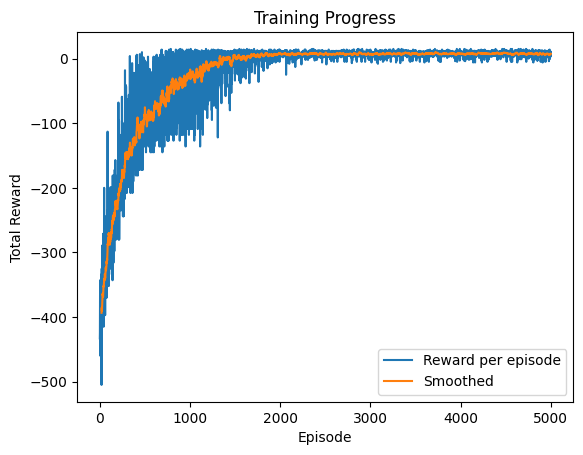

In [6]:
plt.plot(episode_rewards, label="Reward per episode")
window = 20
smoothed = np.convolve(
    episode_rewards,
    np.ones(window)/window,
    mode='valid'
)
plt.plot(range(window-1, len(episode_rewards)), smoothed, label="Smoothed")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Progress")
plt.legend()
plt.show()

In [7]:
print("Average reward (last 100):", np.mean(episode_rewards[-100:]))

Average reward (last 100): 7.11


In [8]:
policy = np.argmax(q_table, axis=1)
print(policy[:20])

[0 4 4 4 0 0 0 2 0 0 0 0 2 0 2 0 5 0 0 0]


Test trained agent

In [9]:
epsilon = 0.0

test_rewards = []

for _ in range(100):
    state, _ = env.reset()
    done = False
    total_reward = 0
    
    while not done:
        action = np.argmax(q_table[state])
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
    
    test_rewards.append(total_reward)

print("Evaluation average:", np.mean(test_rewards))

Evaluation average: 7.74


In [10]:
import time

env = gym.make("Taxi-v3", render_mode="human")

state, _ = env.reset()
done = False
total_reward = 0

while not done:
    action = np.argmax(q_table[state])
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    total_reward += reward
    time.sleep(0.5)   # Slow it down so you can see it

print("Total reward from trained agent:", total_reward)
env.close()

Total reward from trained agent: 5
